# Session 4 – Monte Carlo: Advanced Techniques & Applications

**Topics covered:**

1. Latin Hypercube Sampling
2. Modelling Correlated Variables
3. Risk Tornado Diagrams


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import yfinance as yf
from datetime import date

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Matplotlib style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#cccccc',
    'axes.grid':        True,
    'grid.color':       '#eeeeee',
    'grid.linewidth':   0.7,
    'font.size':        12,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.dpi':       110,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


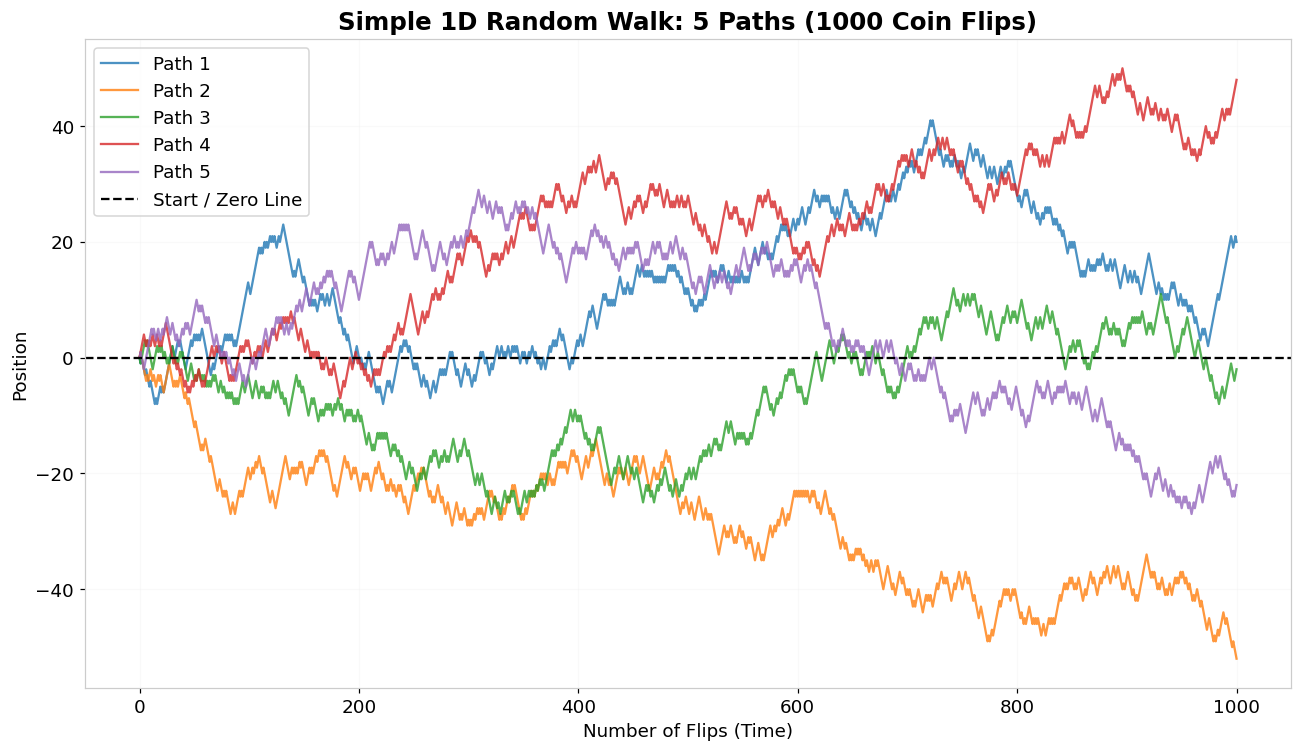

In [ ]:
# But first, a random walk!

# Set seed for reproducibility so the charts look the same every run
np.random.seed(42)

# Parameters
N = 5000          # Number of coin flips (steps) per path
num_paths = 5     # Number of separate walks to plot

# Create the figure
plt.figure(figsize=(12, 7))

# Loop to generate and plot each path
for i in range(num_paths):
    # 1. Flip the coin N times: randomly pick -1 or 1
    flips = np.random.choice([-1, 1], size=N)
    
    # 2. Calculate position: Cumulative sum of the flips
    # We prepend a '0' so the path visually starts at the origin (0,0)
    path = np.concatenate(([0], np.cumsum(flips)))
    
    # 3. Plot the line (Matplotlib automatically assigns a different color to each)
    plt.plot(path, linewidth=1.5, alpha=0.8, label=f'Path {i+1}')

# Formatting the graph to make it look clean
plt.title(f'Simple 1D Random Walk: 5 Paths ({N} Coin Flips)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Flips (Time)', fontsize=12)
plt.ylabel('Position', fontsize=12)

# Add a prominent horizontal line at 0 (the starting line)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Start / Zero Line')

plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()

---
## 1. Latin Hypercube Sampling

**Idea:** Divide the cumulative distribution function (CDF) into $N$ equally probable intervals and draw exactly one sample from each interval. This avoids the clustering that occurs with purely random (Monte Carlo) sampling and produces a more representative distribution with fewer iterations.

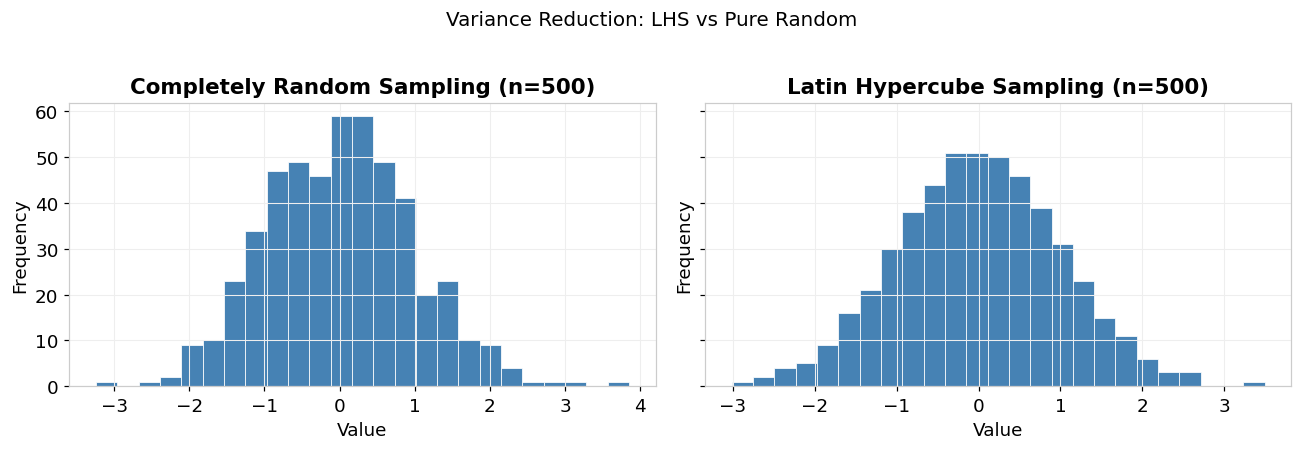

Random  – mean: 0.0068  std: 0.9803
LHS     – mean: 0.0011    std: 1.0016
Theoretical  – mean: 0.0000  std: 1.0000


In [2]:
def latin_hypercube_normal(n: int, mu: float = 0.0, sigma: float = 1.0) -> np.ndarray:
    """Draw n LHS samples from Normal(mu, sigma)."""
    # Divide [0,1] into n equal-probability bins
    # Sample one point uniformly within each bin, then shuffle
    bin_edges = np.arange(n) / n
    u = bin_edges + np.random.uniform(0, 1/n, size=n)   # one sample per bin
    np.random.shuffle(u)                                   # break any ordering
    return stats.norm.ppf(u, loc=mu, scale=sigma)          # inverse CDF transform


def pure_random_normal(n: int, mu: float = 0.0, sigma: float = 1.0) -> np.ndarray:
    return np.random.normal(mu, sigma, size=n)


N = 500
random_samples = pure_random_normal(N)
lhs_samples    = latin_hypercube_normal(N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, data, title in zip(axes,
                            [random_samples, lhs_samples],
                            ['Completely Random Sampling (n=500)',
                             'Latin Hypercube Sampling (n=500)']):
    ax.hist(data, bins=25, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Variance Reduction: LHS vs Pure Random', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Random  – mean: {random_samples.mean():.4f}  std: {random_samples.std():.4f}')
print(f'LHS     – mean: {lhs_samples.mean():.4f}    std: {lhs_samples.std():.4f}')
print(f'Theoretical  – mean: 0.0000  std: 1.0000')

---
## 2. Modelling Correlated Variables

When input variables are correlated, ignoring the correlation leads to incorrect risk estimates.  
We implement the **Iman–Conover method**: generate independent samples, rank them, then rearrange to match a target rank-correlation structure.

Statistic                     Corr=0       Corr=-0.8
----------------------------------------------------
Mean                         9,996.7         9,683.4
Median                       9,817.0         9,682.6
Std Dev                      2,819.6         1,349.0
Min                          1,513.0         2,789.2
Max                         22,654.8        14,840.4


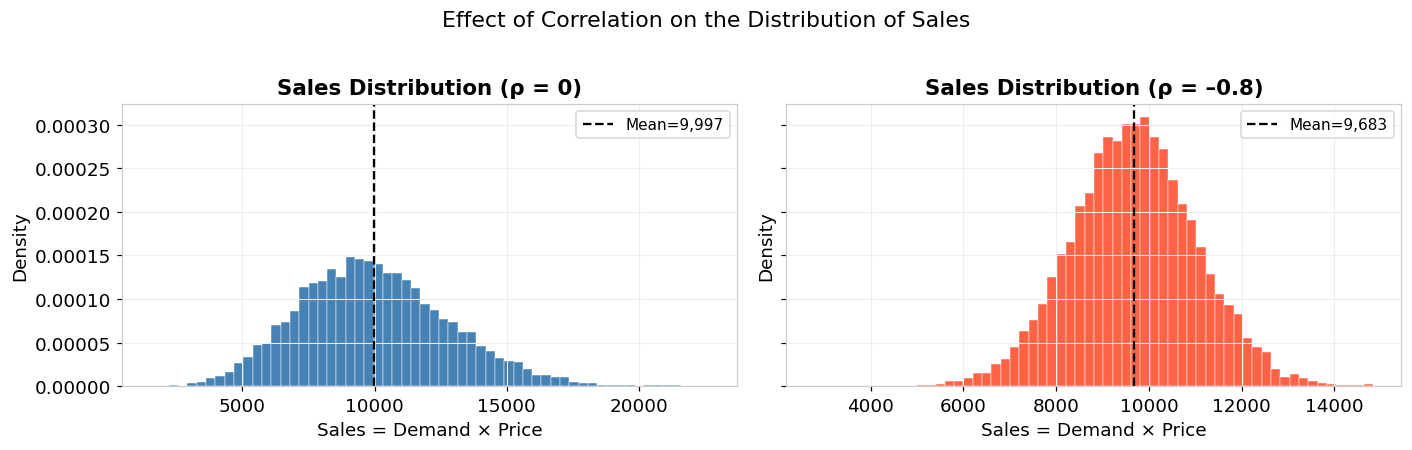

In [3]:
def iman_conover(samples: np.ndarray, corr_matrix: np.ndarray) -> np.ndarray:
    """
    Rearrange columns of `samples` so that their rank correlations
    approximate `corr_matrix` (Iman-Conover method).

    Parameters
    ----------
    samples    : (n_obs, n_vars) array of independently drawn samples
    corr_matrix: target Spearman correlation matrix (n_vars x n_vars)

    Returns
    -------
    correlated : rearranged samples with approximately the desired correlations
    """
    n, k = samples.shape
    # Step 1: convert samples to scores (van der Waerden scores)
    scores = np.zeros_like(samples)
    for j in range(k):
        ranks = stats.rankdata(samples[:, j])
        scores[:, j] = stats.norm.ppf(ranks / (n + 1))

    # Step 2: Cholesky decomposition of target correlation matrix
    P = np.linalg.cholesky(corr_matrix)
    # Step 3: Cholesky of current score correlation
    Q = np.linalg.cholesky(np.corrcoef(scores, rowvar=False))
    # Step 4: apply transformation to scores
    T = scores @ np.linalg.inv(Q).T @ P.T

    # Step 5: reorder each column of samples by the new ranking of T
    correlated = np.zeros_like(samples)
    for j in range(k):
        order = np.argsort(np.argsort(T[:, j]))   # rank order
        sorted_col = np.sort(samples[:, j])
        correlated[:, j] = sorted_col[order]

    return correlated


# ── Simulation ────────────────────────────────────────────────────────────
N_SIM = 10_000
MU, SIGMA = 100, 20

# Draw independent samples for Demand and Price
raw = np.column_stack([
    np.random.normal(MU, SIGMA, N_SIM),
    np.random.normal(MU, SIGMA, N_SIM),
])

# Target correlation matrix (rho = -0.8)
target_corr = np.array([[1.0, -0.8],
                         [-0.8, 1.0]])

corr_samples = iman_conover(raw.copy(), target_corr)

# Sales = Demand * Price
sales_uncorr = raw[:, 0] * raw[:, 1]
sales_corr   = corr_samples[:, 0] * corr_samples[:, 1]

# ── Summary stats ─────────────────────────────────────────────────────────
print(f'{"Statistic":20s} {"Corr=0":>15s} {"Corr=-0.8":>15s}')
print('-' * 52)
for label, fn in [("Mean",    np.mean), ("Median",  np.median),
                   ("Std Dev", np.std),  ("Min",     np.min), ("Max",  np.max)]:
    print(f'{label:20s} {fn(sales_uncorr):15,.1f} {fn(sales_corr):15,.1f}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, data, label, colour in zip(
        axes,
        [sales_uncorr, sales_corr],
        ['Sales Distribution (ρ = 0)', 'Sales Distribution (ρ = –0.8)'],
        ['steelblue', 'tomato']):
    ax.hist(data, bins=60, color=colour, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(label)
    ax.set_xlabel('Sales = Demand × Price')
    ax.set_ylabel('Density')
    ax.axvline(np.mean(data), color='black', linewidth=1.5, linestyle='--', label=f'Mean={np.mean(data):,.0f}')
    ax.legend(fontsize=10)

plt.suptitle('Effect of Correlation on the Distribution of Sales', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Risk Tornado Diagram

Compute the Pearson correlation between each input variable and the output (NPV), sort by absolute value, and plot as a horizontal bar chart.

                  Correlation   AbsCorr
Var Cost %          -0.231142  0.231142
Initial Fare         0.355039  0.355039
Pass. Multiplier     0.616406  0.616406
Fare Increase %      0.652643  0.652643


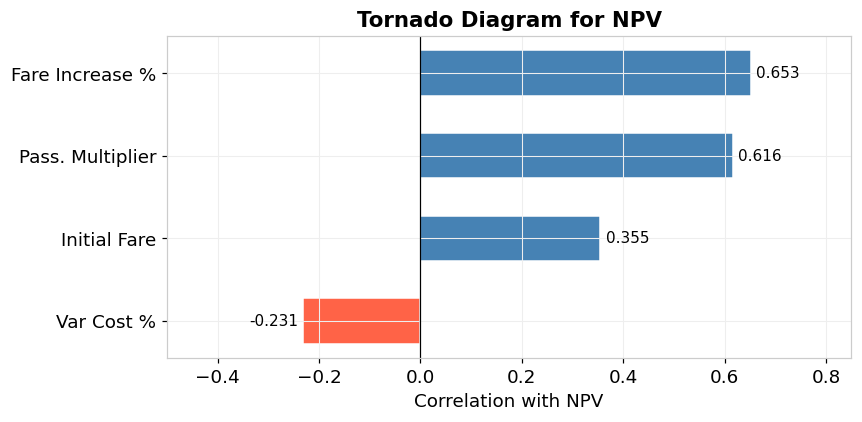

In [4]:
# ── Synthetic LEA airline NPV simulation ──────────────────────────────────
# We create a simplified NPV model for illustration.
# All inputs are drawn independently.

N_SIM = 10_000
rng = np.random.default_rng(0)

# Input distributions (triangular parameterised as (low, mode, high))
def triang(low, mode, high, n):
    c = (mode - low) / (high - low)
    return stats.triang.rvs(c, loc=low, scale=high-low, size=n)

pass_mult     = rng.normal(1.0, 0.10, N_SIM)          # passenger multiplier
init_fare     = triang(57, 73, 75, N_SIM)              # £/ticket
fare_increase = triang(0.00, 0.08, 0.10, N_SIM)       # annual %
var_cost_pct  = triang(0.10, 0.14, 0.25, N_SIM)       # % of revenue

# Simplified NPV formula
YEARS, BASE_PSGR, DISC_RATE = 10, 100_000, 0.08
npv = np.zeros(N_SIM)
for t in range(1, YEARS + 1):
    revenue = pass_mult * BASE_PSGR * init_fare * (1 + fare_increase)**t
    costs   = revenue * var_cost_pct
    npv    += (revenue - costs) / (1 + DISC_RATE)**t
npv -= 5_000_000  # initial investment

# ── Compute Pearson correlations ──────────────────────────────────────────
inputs = {
    'Var Cost %':       var_cost_pct,
    'Initial Fare':     init_fare,
    'Fare Increase %':  fare_increase,
    'Pass. Multiplier': pass_mult,
}

corrs = {name: np.corrcoef(vals, npv)[0, 1] for name, vals in inputs.items()}
corr_df = (pd.DataFrame.from_dict(corrs, orient='index', columns=['Correlation'])
             .assign(AbsCorr=lambda x: x['Correlation'].abs())
             .sort_values('AbsCorr'))

print(corr_df.to_string())

# ── Tornado diagram ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colours = ['tomato' if v < 0 else 'steelblue' for v in corr_df['Correlation']]
bars = ax.barh(corr_df.index, corr_df['Correlation'], color=colours, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_df['Correlation']):
    xpos = val + (0.01 if val >= 0 else -0.01)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_xlabel('Correlation with NPV')
ax.set_title('Tornado Diagram for NPV')
ax.set_xlim(-0.5, 0.85)
plt.tight_layout()
plt.show()